In [2]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist

import vector as vec

import numba
from more_itertools import set_partitions

In [3]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }
    

In [4]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:2]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2024.7.0 (target date: 2024-06-30 11:59:59-05:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [5]:
len(small_events.ScoutingJet.compute())

105144

In [6]:
scouting_selection = PackedSelection()

scouting_selection.add("SixJets", ak.num(small_events.ScoutingJet, axis=1) >5)

In [7]:
good_events = small_events[scouting_selection.all("SixJets")]
selected_jets = good_events.ScoutingJet[:,0:6]
trijet = ak.combinations(selected_jets, 3, fields=["j1","j2","j3"])

In [8]:
total_p4 = selected_jets[:,0] + selected_jets[:,1] + selected_jets[:,2] + selected_jets[:,3] + selected_jets[:,4] + selected_jets[:,5]
cart = ak.cartesian([total_p4,trijet])
vector = (cart['1'].j1 + cart['1'].j2 + cart['1'].j3)
other_vector = (cart['0'] - vector)

In [9]:
vm = vector.mass
ovm =other_vector.mass
masym = (vm - ovm)/(vm + ovm)

In [10]:
vec.register_awkward()

good_events["Trijet"] = ak.zip(
    {
        "px": trijet.j1.px + trijet.j2.px + trijet.j3.px, 
        "py": trijet.j1.py + trijet.j2.py + trijet.j3.py, 
        "pz": trijet.j1.pz + trijet.j2.pz + trijet.j3.pz,
        "e": trijet.j1.E + trijet.j2.E + trijet.j3.E,
        "masym": masym
    },
    with_name="Momentum4D"
)

In [38]:
h1 = Hist(
    hist.axis.Regular(50, 100, 300, name="x", label="Trijet Invariant Mass"),
    hist.axis.StrCategory(['Full', 'Cut'], growth=True, name='dataset'),
    hist.storage.Weight()
)
h1.fill(ak.flatten(good_events.Trijet.m.compute()), "Full")
h1.fill(ak.flatten(good_events.Trijet[good_events.Trijet.masym < 0.05].m.compute()), "Cut")

Hist(
  Regular(50, 100, 300, name='x', label='Trijet Invariant Mass'),
  StrCategory(['Full', 'Cut'], growth=True, name='dataset'),
  storage=Weight()) # Sum: WeightedSum(value=1.89504e+06, variance=1.89504e+06) (WeightedSum(value=2.82721e+06, variance=2.82721e+06) with flow)

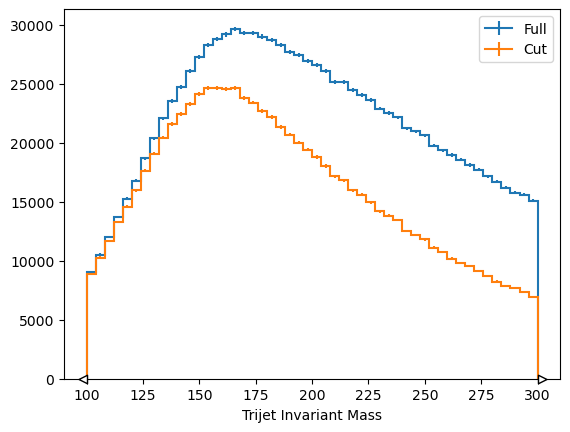

In [40]:
h1.plot(stack=False, histtype="step")
plt.legend()